In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam, Adagrad
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
max_iters = 300_000


DATA = True
if DATA:
    np.random.seed(0)
    data = np.random.normal(
        loc=mu_prior,
        scale=sigma_prior,
        size=100).astype(np.float32)


    true_mu_post = (sigma_like**2 * mu_prior + sigma_prior**2 * data.mean()) / (sigma_like**2 + sigma_prior**2)
    true_sigma_post = np.sqrt(1 / (1/sigma_prior**2 + 100/sigma_like**2))

else:
    data = []
    # compute true posteriors
    true_mu_post = mu_prior
    true_sigma_post = sigma_prior

def run_restart(seed):
    np.random.seed(seed)
    # normal models
    def single_model(y):
        mu = numpyro.sample("mu", dist.Normal(mu_prior, sigma_prior))
        numpyro.sample("obs", dist.Normal(mu, sigma_like), obs=y)
    def multi_model(y):
        mu = numpyro.sample("mu", dist.Normal(mu_prior, sigma_prior))
        numpyro.sample("obs", dist.Normal(mu, sigma_like), obs=y)
    y_data = jnp.array(data)

    single_guide = AutoNormal(single_model)
    multi_guide = AutoNormal(multi_model)

    adam_step = 5e-4 # default 5e-4 "default" bc used often in examples, default eps = 1e-8
    optimizer = Adam(adam_step, eps=1e-8)
    single_elbo = Trace_ELBO()
    multi_elbo = Trace_ELBO(num_particles=100)

    single_svi = SVI(single_model, single_guide, optimizer, loss=single_elbo)
    multi_svi = SVI(multi_model, multi_guide, optimizer, loss=multi_elbo)


    def run_svi(rng_key, y_data, svi_model):
        @jax.jit
        def run_single_svi_loop(rng_key, y_data):
            svi_state = svi_model.init(rng_key, y_data)
            def body_fn(i, val):
                svi_state, tracker = val
                svi_state, loss = svi_model.update(svi_state, y_data)
                params = svi_model.get_params(svi_state)
                tracker = {
                    'mu_loc': tracker['mu_loc'].at[i].set(params['mu_auto_loc']),
                    'std_loc': tracker['std_loc'].at[i].set(params['mu_auto_scale'])
                }
                return svi_state, tracker
            tracker = {
                'mu_loc': jnp.zeros(max_iters),
                'std_loc': jnp.zeros(max_iters)
            }
            final_state, final_tracker = jax.lax.fori_loop(0, max_iters, body_fn, (svi_state, tracker))
            final_elbo = svi_model.evaluate(final_state, y_data)
            return final_elbo, final_tracker
        return run_single_svi_loop(rng_key, y_data)

    single_elbo, single_tracker = run_svi(jax.random.PRNGKey(seed), y_data, single_svi)
    multi_elbo, multi_tracker = run_svi(jax.random.PRNGKey(seed+1000), y_data, multi_svi)
    return single_elbo, single_tracker, multi_elbo, multi_tracker

In [3]:
results = []
for seed in tqdm(range(100)):
    result = run_restart(seed)
    results.append(result)

100%|██████████| 100/100 [17:33<00:00, 10.54s/it]


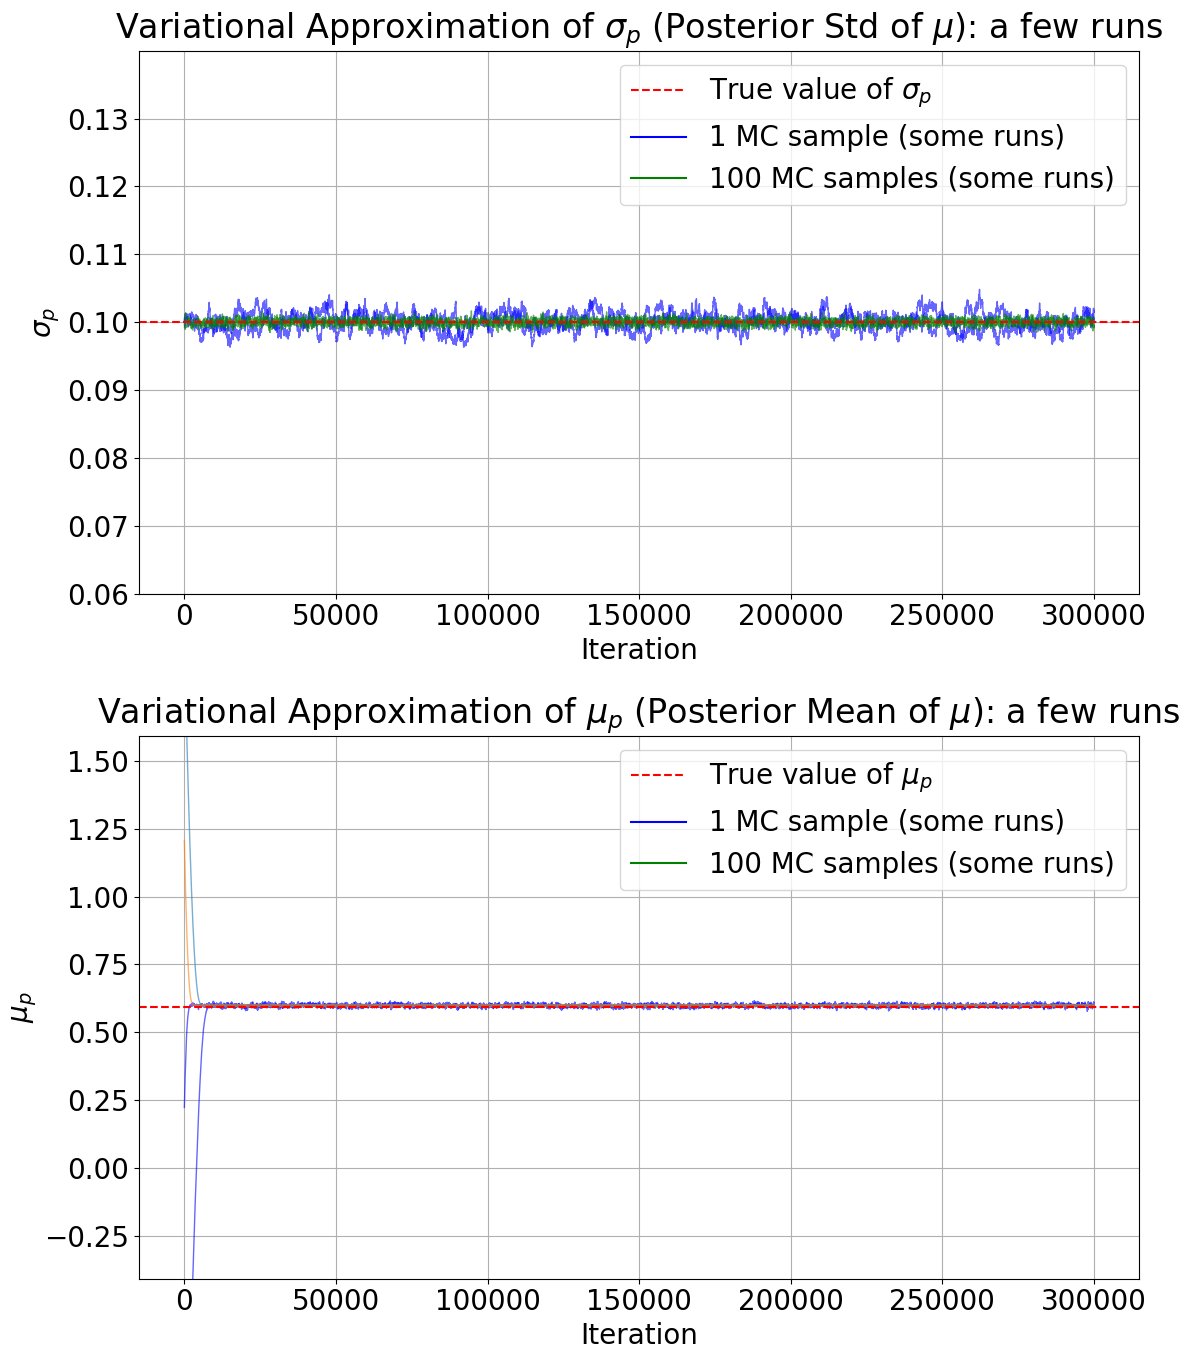

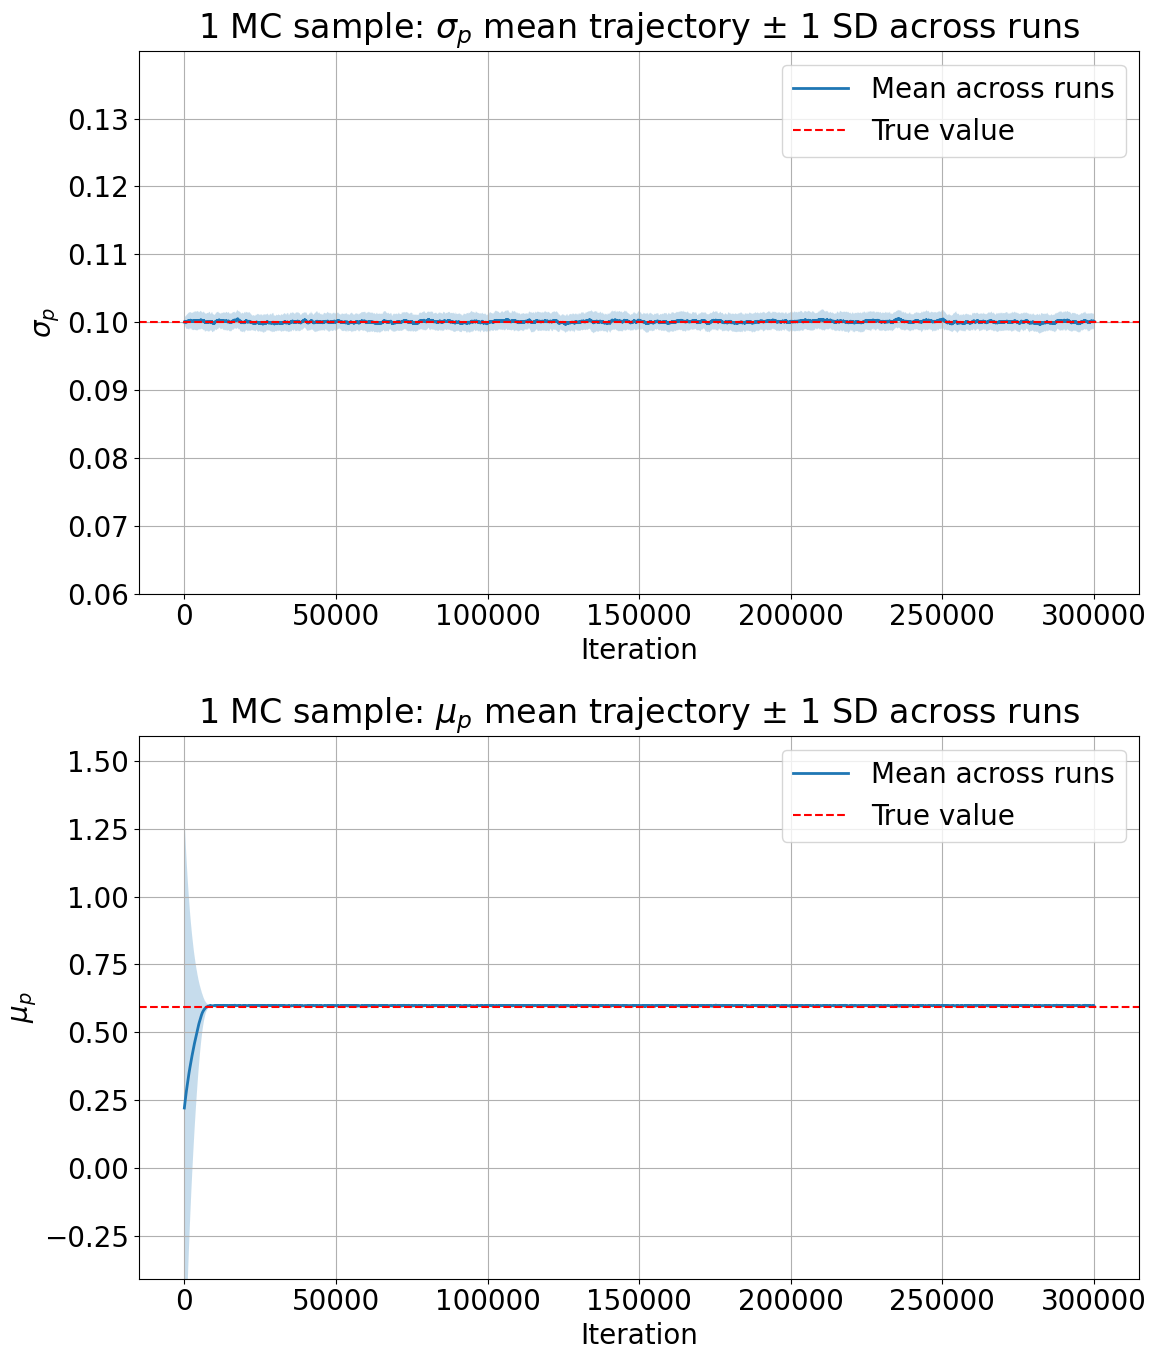

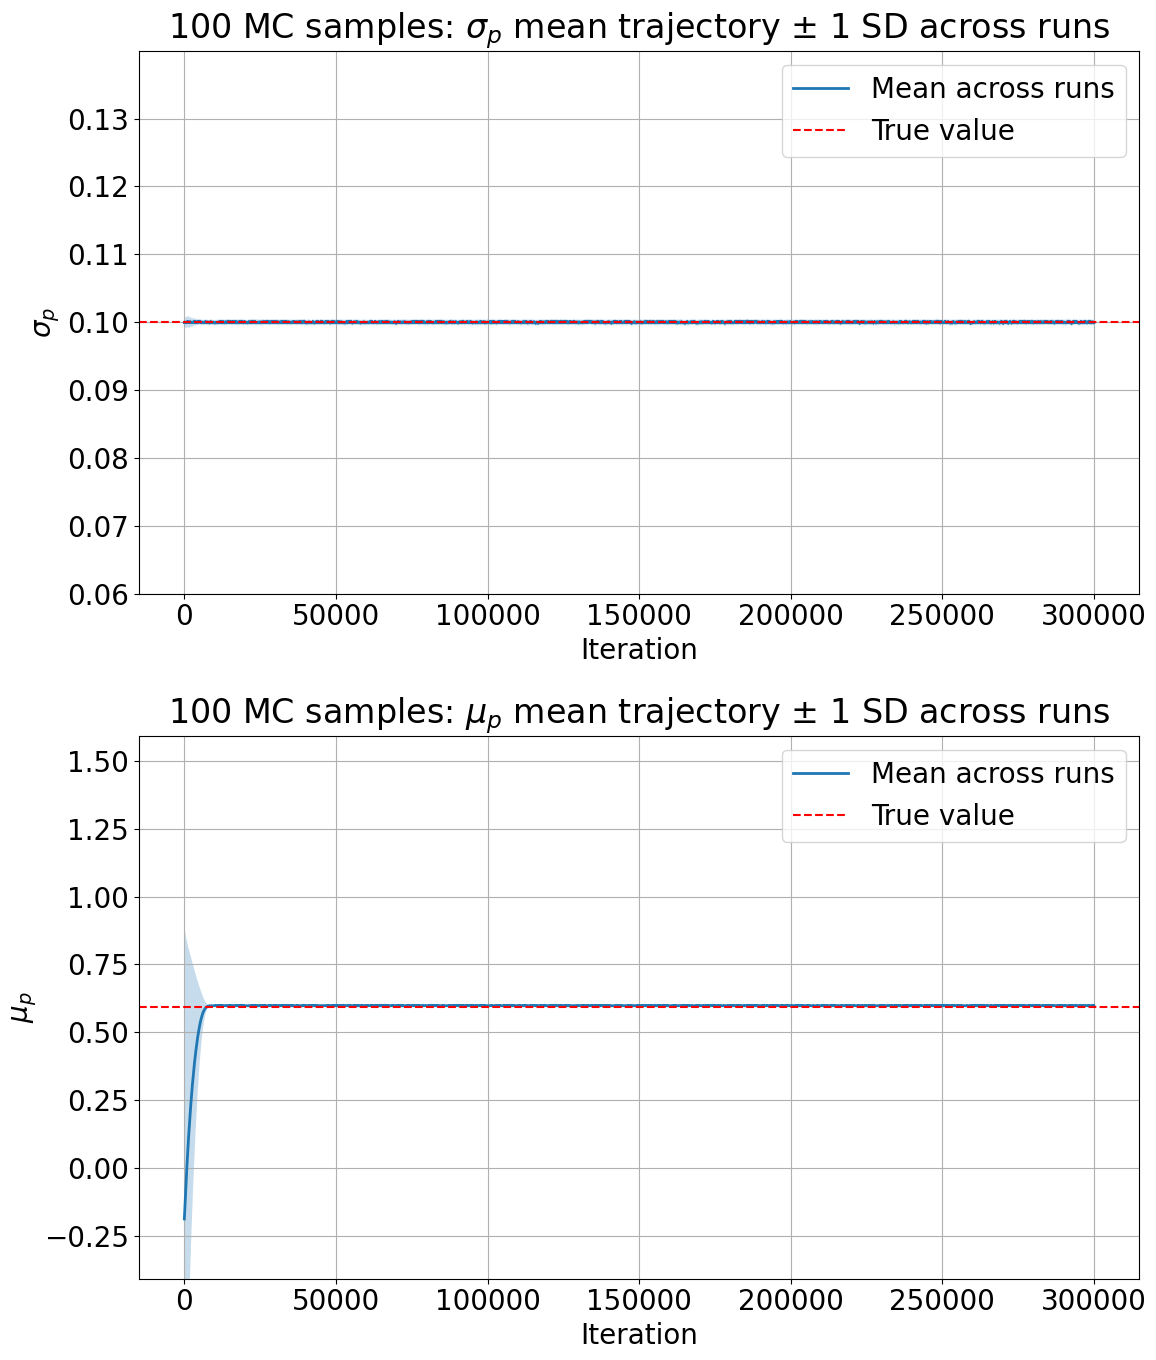

In [9]:
plt.rcParams.update({'font.size': 20})


# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_elbo, single_tracker, multi_elbo, multi_tracker in results:
    single_means.append(single_tracker['mu_loc'])
    single_stds.append(single_tracker['std_loc'])
    multi_means.append(multi_tracker['mu_loc'])
    multi_stds.append(multi_tracker['std_loc'])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(true_sigma_post, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(true_mu_post, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, true_sigma_post,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

plot_mean_band(
    axs[1], x, single_means, true_mu_post,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, true_sigma_post,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

plot_mean_band(
    axs[1], x, multi_means, true_mu_post,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

plt.tight_layout()
plt.show()